# Prototype

## Channel Model – Key Relations

$th(x) = gpc \left( 1 - \exp(-c Q(x) t_p) \right)$  

$Q(x) = Q_0 \exp(-x/x_s)$  

$x_s \propto \sqrt{T/p_A}$

In [7]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Channel Profile

In [8]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [9]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.00572 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 219 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [10]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

model.pA = max(model.pA, 1e-3)
model.K = max(model.K, 1e-6)


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio evaluations infeasible


===== DEBUG: ratio optimization =====
DEBUG EMPTY
All ratio eval

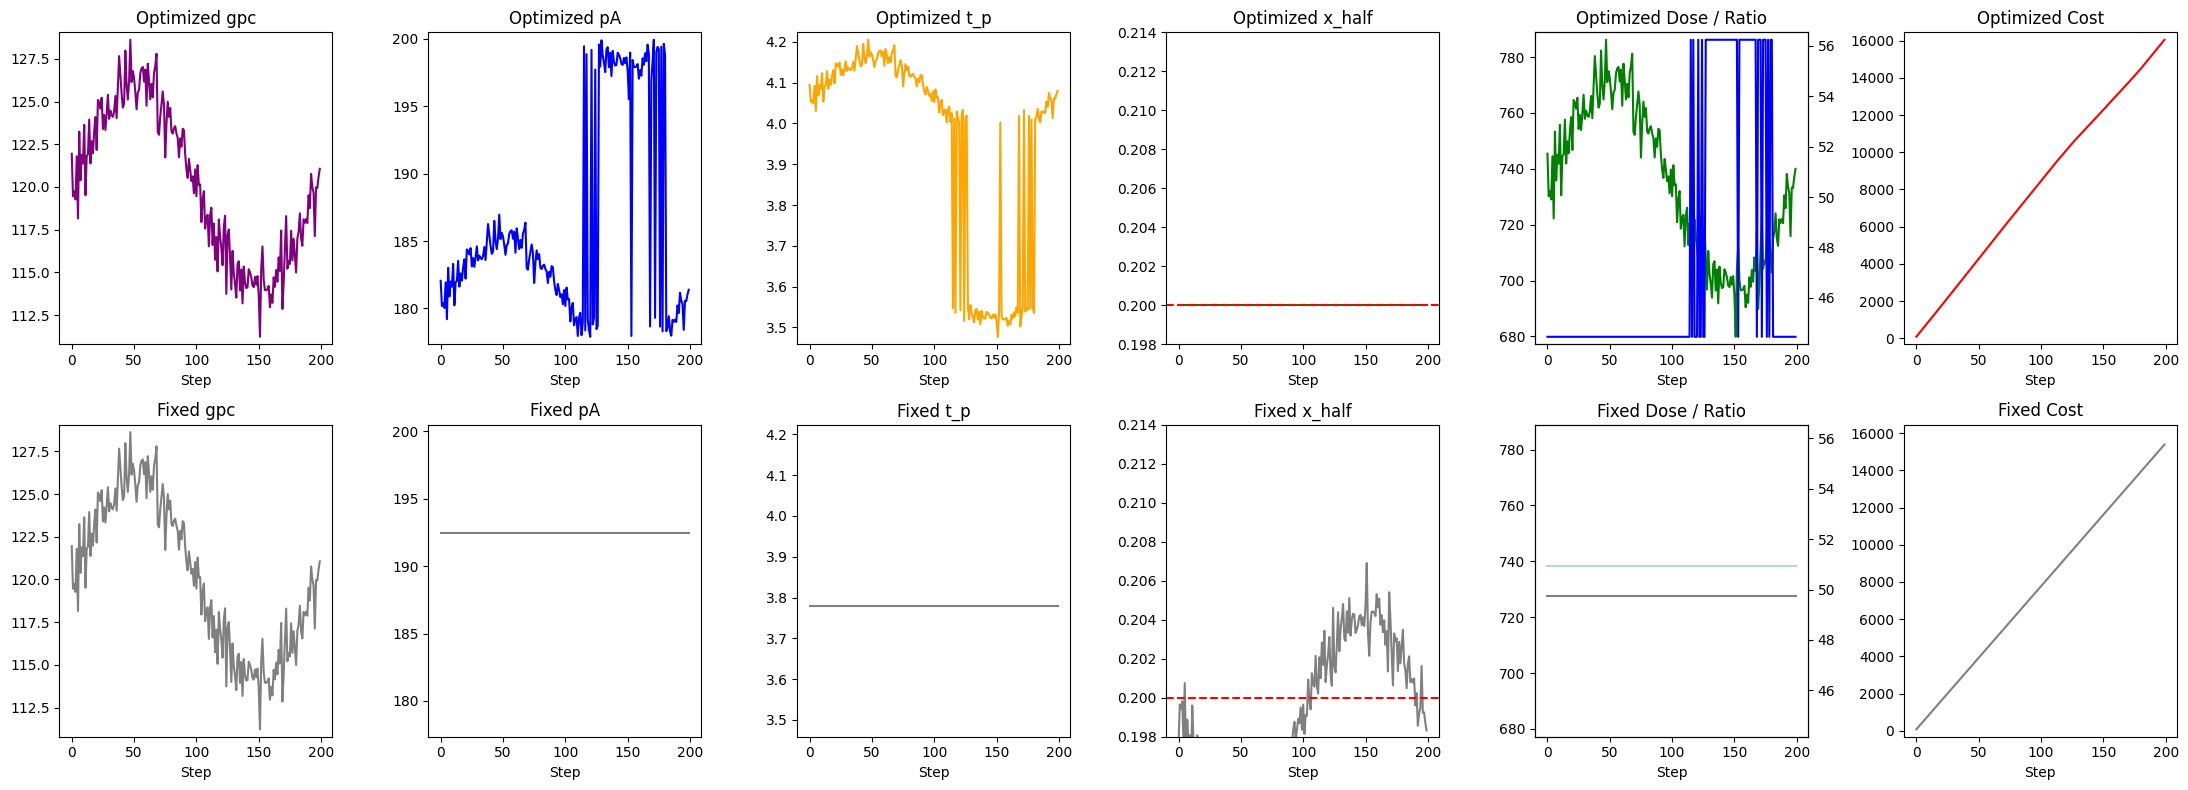

In [19]:
# ============================================================
# 0. import
# ============================================================
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ============================================================
# 1. gpc 생성
# ============================================================
def generate_gpc(N=200, seed=0):
    np.random.seed(seed)

    gpc_nominal = 1.2e-10
    amp = 0.05
    period = 200
    noise_level = 0.01

    steps = np.arange(N)

    gpc_base = gpc_nominal * (
        1 + amp * np.sin(2 * np.pi * steps / period)
    )

    noise = 1 + noise_level * np.random.randn(N)
    gpc = gpc_base * noise

    return np.clip(gpc, 1e-15, None)


gpc_data = generate_gpc(N=200, seed=1)


def get_gpc(k):
    return float(gpc_data[min(k, len(gpc_data)-1)])


# ============================================================
# 2. cost
# ============================================================
def cost_function(pA, tp, pA_prev, tp_max):
    tp_n = tp / tp_max

    return (
        100 * tp_n 
        + tp_n * pA / (250)
        + 1 * pA / 250
    )


# ============================================================
# 3. prepare
# ============================================================
def prepare_model(model):
    model.collision_rate()
    model.calc_adsorption_density()
    model.calc_za()
    model.calc_hydro_diameter()
    model.calc_Deff()


# ============================================================
# 4. x_half
# ============================================================
def find_x_half(pA_profile, x):
    pA_profile = np.asarray(pA_profile)
    pA_in = pA_profile[0]

    if pA_in <= 0 or not np.isfinite(pA_in):
        return 0.0

    half = 0.5 * pA_in
    idx = np.where(pA_profile <= half)[0]

    if len(idx) == 0:
        return float(x[-1])

    i = idx[0]
    if i == 0:
        return float(x[0])

    x0, x1 = x[i-1], x[i]
    y0, y1 = pA_profile[i-1], pA_profile[i]

    if y1 == y0:
        return float(x0)

    return float(x0 + (half - y0) * (x1 - x0) / (y1 - y0))


# ============================================================
# 5. evaluate
# ============================================================
def evaluate(pA, tp, model, x, last_theta):
    m = copy.copy(model)

    m.pA = max(float(pA), 1e-6)
    m.t_p = max(float(tp), 1e-9)

    prepare_model(m)

    try:
        thickness, next_theta, info = m.approx(x, last_theta)
        x_half = find_x_half(info['pA'], x)

        if not np.isfinite(x_half):
            x_half = 0.0

        return thickness, next_theta, x_half

    except Exception:
        return np.zeros_like(x), last_theta.copy(), 0.0


from scipy.optimize import minimize_scalar


from scipy.optimize import minimize_scalar


# ============================================================
# 6. Optimized step
# nested optimization:
# outer = ratio optimization
# inner = minimum feasible dose search
# ============================================================
from scipy.optimize import minimize_scalar


def mpc_step(
    model,
    x,
    last_theta,
    l_0,
    pA_bounds,
    tp_bounds,
    bisect_iter=40,
):

    pA_prev = model.pA
    tp_max = tp_bounds[1]

    pA_min, pA_max = pA_bounds
    tp_min, tp_max_bound = tp_bounds

    # --------------------------------------------------------
    # ratio bounds
    # --------------------------------------------------------
    r_min = pA_min / tp_max_bound
    r_max = pA_max / tp_min

    best_xh = -np.inf
    best_xh_u = None

    # --------------------------------------------------------
    # dose, ratio -> pA, tp
    # --------------------------------------------------------
    def dose_ratio_to_pa_tp(D, r):

        pA = np.sqrt(D * r)
        tp = np.sqrt(D / r)

        return float(pA), float(tp)

    # --------------------------------------------------------
    # valid dose bounds for ratio
    # --------------------------------------------------------
    def dose_bounds_for_ratio(r):

        D_low = max(
            pA_min**2 / r,
            tp_min**2 * r,
        )

        D_high = min(
            pA_max**2 / r,
            tp_max_bound**2 * r,
        )

        return D_low, D_high

    # --------------------------------------------------------
    # inner solve:
    # minimum feasible dose for ratio r
    # --------------------------------------------------------
    def solve_boundary_dose(r):

        nonlocal best_xh
        nonlocal best_xh_u

        D_low, D_high = dose_bounds_for_ratio(r)

        if D_low >= D_high:
            return None

        # high point check
        pA_hi, tp_hi = dose_ratio_to_pa_tp(D_high, r)

        _, _, xh_hi = evaluate(
            pA_hi,
            tp_hi,
            model,
            x,
            last_theta,
        )

        if xh_hi > best_xh:
            best_xh = xh_hi
            best_xh_u = (pA_hi, tp_hi)

        # infeasible even at max dose
        if xh_hi < l_0:
            return None

        # low point check
        pA_lo, tp_lo = dose_ratio_to_pa_tp(D_low, r)

        _, _, xh_lo = evaluate(
            pA_lo,
            tp_lo,
            model,
            x,
            last_theta,
        )

        # already feasible
        if xh_lo >= l_0:
            D_star = D_low

        else:

            # --------------------------------------------
            # bisection
            # --------------------------------------------
            lo = D_low
            hi = D_high

            for _ in range(bisect_iter):

                mid = 0.5 * (lo + hi)

                pA_mid, tp_mid = dose_ratio_to_pa_tp(mid, r)

                _, _, xh_mid = evaluate(
                    pA_mid,
                    tp_mid,
                    model,
                    x,
                    last_theta,
                )

                if xh_mid >= l_0:
                    hi = mid
                else:
                    lo = mid

            D_star = hi

        pA_star, tp_star = dose_ratio_to_pa_tp(D_star, r)

        _, _, xh_star = evaluate(
            pA_star,
            tp_star,
            model,
            x,
            last_theta,
        )

        return D_star, pA_star, tp_star, xh_star

    # --------------------------------------------------------
    # DEBUG storage
    # --------------------------------------------------------
    debug_rows = []


    # --------------------------------------------------------
    # outer objective:
    # optimize ratio continuously
    # --------------------------------------------------------
    def ratio_objective(log_r):

        r = np.exp(log_r)

        result = solve_boundary_dose(r)

        if result is None:
            return 1e12

        D_star, pA_star, tp_star, xh_star = result

        base = cost_function(
            pA_star,
            tp_star,
            pA_prev,
            tp_max,
        )

        # ----------------------------------------------------
        # ratio penalty
        # ----------------------------------------------------
        r_prev = model.pA / model.t_p

        ratio_penalty = 0 * (np.log(r / r_prev))**2

        cost = base + ratio_penalty

        # ----------------------------------------------------
        # DEBUG logging
        # ----------------------------------------------------
        debug_rows.append({
            "r": r,
            "D_star": D_star,
            "pA": pA_star,
            "tp": tp_star,
            "xh": xh_star,
            "base_cost": base,
            "total_cost": cost,
        })

        return cost


    # --------------------------------------------------------
    # outer optimization
    # --------------------------------------------------------
    result = minimize_scalar(
        ratio_objective,
        bounds=(np.log(r_min), np.log(r_max)),
        method="bounded",
        options={"xatol": 1e-3},
    )

    # --------------------------------------------------------
    # DEBUG print
    # --------------------------------------------------------
    debug_df = pd.DataFrame(debug_rows)

    print("\n===== DEBUG: ratio optimization =====")

    if len(debug_df) == 0:

        print("DEBUG EMPTY")
        print("All ratio evaluations infeasible")

    else:

        print(
            debug_df
            .sort_values("total_cost")
            .head(20)
        )

    print("=====================================\n")

    # --------------------------------------------------------
    # final solution
    # --------------------------------------------------------
    if not result.success:

        P, T = best_xh_u

        cost = cost_function(
            P,
            T,
            pA_prev,
            tp_max,
        )

        return (
            P,
            T,
            cost,
            best_xh,
            False,
            "fallback",
        )

    # --------------------------------------------------------
    # final solution
    # --------------------------------------------------------
    r_star = np.exp(result.x)

    final = solve_boundary_dose(r_star)

    # optimizer가 infeasible edge로 간 경우
    if final is None:

        # 주변 ratio들 재탐색
        r_candidates = np.exp(
            np.linspace(
                np.log(r_min),
                np.log(r_max),
                50,
            )
        )

        best_local = None
        best_cost = np.inf

        for r_try in r_candidates:

            tmp = solve_boundary_dose(r_try)

            if tmp is None:
                continue

            D_try, P_try, T_try, xh_try = tmp

            c_try = cost_function(
                P_try,
                T_try,
                pA_prev,
                tp_max,
            )

            if c_try < best_cost:
                best_cost = c_try
                best_local = (P_try, T_try, xh_try)

        # 진짜 feasible 없으면 fallback
        if best_local is None:

            P, T = best_xh_u

            cost = cost_function(
                P,
                T,
                pA_prev,
                tp_max,
            )

            return (
                P,
                T,
                cost,
                best_xh,
                False,
                "fallback",
            )

        P, T, xh = best_local

        cost = cost_function(
            P,
            T,
            pA_prev,
            tp_max,
        )

        return (
            P,
            T,
            cost,
            xh,
            True,
            "ratio_refine",
        )

    # 정상
    D_star, P, T, xh = final

    cost = cost_function(
        P,
        T,
        pA_prev,
        tp_max,
    )

    return (
        P,
        T,
        cost,
        xh,
        True,
        "nested_opt",
    )

# ============================================================
# 7. MPC run
# ============================================================
def run_mpc(x, steps, l_0, T_fixed, pA_bounds, tp_bounds):

    model = channelModel()
    model.T = T_fixed
    model.pA = np.mean(pA_bounds)
    model.t_p = np.mean(tp_bounds)

    last_theta = np.zeros_like(x)
    hist = []
    total = 0.0

    for kk in range(steps):
        model.gpc = get_gpc(kk)

        pA, tp, _, _, feasible, source = mpc_step(
            model,
            x,
            last_theta,
            l_0,
            pA_bounds,
            tp_bounds,
        )

        _, last_theta, xh = evaluate(pA, tp, model, x, last_theta)

        cost = cost_function(pA, tp, model.pA, tp_bounds[1])
        total += cost

        hist.append({
            "step": kk,
            "pA": pA,
            "t_p": tp,
            "pA_tp": pA * tp,
            "gpc": model.gpc,
            "x_half": xh,
            "ok": xh >= l_0,
            "feasible": feasible,
            "source": source,
            "cost": cost,
            "total": total,
        })

        model.pA = pA
        model.t_p = tp

    return pd.DataFrame(hist)


# ============================================================
# 8. fixed run
# ============================================================
def run_fixed(x, steps, l_0, T_fixed, pA_fixed, tp_fixed, tp_bounds):

    model = channelModel()
    model.T = T_fixed
    model.pA = pA_fixed
    model.t_p = tp_fixed

    last_theta = np.zeros_like(x)
    hist = []
    total = 0.0

    for kk in range(steps):
        model.gpc = get_gpc(kk)

        _, last_theta, xh = evaluate(
            pA_fixed, tp_fixed, model, x, last_theta
        )

        cost = cost_function(pA_fixed, tp_fixed, pA_fixed, tp_bounds[1])
        total += cost

        hist.append({
            "step": kk,
            "pA": pA_fixed,
            "t_p": tp_fixed,
            "pA_tp": pA_fixed * tp_fixed,
            "gpc": model.gpc,
            "x_half": xh,
            "ok": xh >= l_0,
            "cost": cost,
            "total": total,
        })

    return pd.DataFrame(hist)


# ============================================================
# 9. 실행 설정
# ============================================================
steps = 200

x = np.linspace(0, 1e-3, 200)
l_0 = 0.2e-3
T_fixed = 673

pA_bounds = (1, 200)
tp_bounds = (0.01, 5)

pA_fixed = 192.5
tp_fixed = 3.78

# steps = 200

# x = np.linspace(0, 1e-3, 200)
# l_0 = 0.2e-3
# T_fixed = 673

# pA_bounds = (1, 200)
# tp_bounds = (0.01, 5)

# pA_fixed = 192.5*1.04
# tp_fixed = 3.78*1.04



# ============================================================
# 10. 실행
# ============================================================
mpc_df = run_mpc(
    x=x,
    steps=steps,
    l_0=l_0,
    T_fixed=T_fixed,
    pA_bounds=pA_bounds,
    tp_bounds=tp_bounds,
)

fix_df = run_fixed(
    x=x,
    steps=steps,
    l_0=l_0,
    T_fixed=T_fixed,
    pA_fixed=pA_fixed,
    tp_fixed=tp_fixed,
    tp_bounds=tp_bounds,
)


# ============================================================
# 11. 비교 출력
# ============================================================
# ============================================================
# 11. 출력 (용어 수정)
# ============================================================

print("Optimized violations:", (~mpc_df["ok"]).sum())
print("Fixed violations:", (~fix_df["ok"]).sum())

print("Optimized total cost:", mpc_df["total"].iloc[-1])
print("Fixed total cost:", fix_df["total"].iloc[-1])

print("Optimized infeasible fallback:", (~mpc_df["feasible"]).sum())
print(mpc_df["source"].value_counts())


# ============================================================
# 파생 변수
# ============================================================
mpc_df["dose"] = mpc_df["pA"] * mpc_df["t_p"]
mpc_df["ratio"] = mpc_df["pA"] / mpc_df["t_p"]

fix_df["dose"] = fix_df["pA"] * fix_df["t_p"]
fix_df["ratio"] = fix_df["pA"] / fix_df["t_p"]


# ============================================================
# y-limit helper
# ============================================================
def get_lim(a, b, scale=1.05):
    vmin = min(np.min(a), np.min(b))
    vmax = max(np.max(a), np.max(b))
    center = 0.5 * (vmin + vmax)
    half = 0.5 * (vmax - vmin) * scale
    return center - half, center + half


# ============================================================
# limits 계산
# ============================================================
gpc_lim = get_lim(mpc_df["gpc"] * 1e12, fix_df["gpc"] * 1e12)
pA_lim    = get_lim(mpc_df["pA"], fix_df["pA"])
tp_lim    = get_lim(mpc_df["t_p"], fix_df["t_p"])
xh_center = l_0 * 1e3
xh_lim = (xh_center * 0.99, xh_center * 1.07)
dose_lim  = get_lim(mpc_df["dose"], fix_df["dose"])
ratio_lim = get_lim(mpc_df["ratio"], fix_df["ratio"])
cost_lim  = get_lim(mpc_df["total"], fix_df["total"])


# ============================================================
# plotting
# ============================================================
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
steps_arr = mpc_df["step"]

# =============================
# ROW 1: Optimized
# =============================

# gpc
axes[0, 0].plot(steps_arr, mpc_df["gpc"] * 1e12, color='purple')
axes[0, 0].set_title("Optimized gpc")
axes[0, 0].set_ylim(gpc_lim)

# pA
axes[0, 1].plot(steps_arr, mpc_df["pA"], color='blue')
axes[0, 1].set_title("Optimized pA")
axes[0, 1].set_ylim(pA_lim)

# t_p
axes[0, 2].plot(steps_arr, mpc_df["t_p"], color='orange')
axes[0, 2].set_title("Optimized t_p")
axes[0, 2].set_ylim(tp_lim)

# x_half
axes[0, 3].plot(steps_arr, mpc_df["x_half"] * 1e3, color='green')
axes[0, 3].axhline(l_0 * 1e3, linestyle="--", color='red')
axes[0, 3].set_title("Optimized x_half")
axes[0, 3].set_ylim(xh_lim)

# dose + ratio
ax1_opt = axes[0, 4]
ax2_opt = ax1_opt.twinx()

ax1_opt.plot(steps_arr, mpc_df["dose"], color='green')
ax2_opt.plot(steps_arr, mpc_df["ratio"], color='blue')

ax1_opt.set_title("Optimized Dose / Ratio")
ax1_opt.set_ylim(dose_lim)
ax2_opt.set_ylim(ratio_lim)

# cost
axes[0, 5].plot(steps_arr, mpc_df["total"], color='red')
axes[0, 5].set_title("Optimized Cost")
axes[0, 5].set_ylim(cost_lim)


# =============================
# ROW 2: Fixed
# =============================

# gpc
axes[1, 0].plot(steps_arr, fix_df["gpc"] * 1e12, color='gray')
axes[1, 0].set_title("Fixed gpc")
axes[1, 0].set_ylim(gpc_lim)

# pA
axes[1, 1].plot(steps_arr, fix_df["pA"], color='gray')
axes[1, 1].set_title("Fixed pA")
axes[1, 1].set_ylim(pA_lim)

# t_p
axes[1, 2].plot(steps_arr, fix_df["t_p"], color='gray')
axes[1, 2].set_title("Fixed t_p")
axes[1, 2].set_ylim(tp_lim)

# x_half
axes[1, 3].plot(steps_arr, fix_df["x_half"] * 1e3, color='gray')
axes[1, 3].axhline(l_0 * 1e3, linestyle="--", color='red')
axes[1, 3].set_title("Fixed x_half")
axes[1, 3].set_ylim(xh_lim)

# dose + ratio
ax1_fix = axes[1, 4]
ax2_fix = ax1_fix.twinx()

ax1_fix.plot(steps_arr, fix_df["dose"], color='gray')
ax2_fix.plot(steps_arr, fix_df["ratio"], color='lightblue')

ax1_fix.set_title("Fixed Dose / Ratio")
ax1_fix.set_ylim(dose_lim)
ax2_fix.set_ylim(ratio_lim)

# cost
axes[1, 5].plot(steps_arr, fix_df["total"], color='gray')
axes[1, 5].set_title("Fixed Cost")
axes[1, 5].set_ylim(cost_lim)


# =============================
# 공통 설정
# =============================
for i in range(2):
    for j in range(6):
        axes[i, j].set_xlabel("Step")

plt.tight_layout()
plt.show()